# Notebook 1 — Exemplo Ruim e Desbalanceado: Fingerprints + Faces

Este notebook foi desenhado para a aula de **Profiling, Gargalos e Balanceamento de Carga** como um **caso propositalmente ruim**.

A ideia não é elegância algorítmica. A ideia é gerar um pipeline com:

- **overhead desnecessário**;
- **mistura ruim de I/O e computação**;
- **granularidade inadequada**;
- **particionamento estático ruim**;
- **desbalanceamento entre workers**.

## Cenário
Temos dois tipos de imagem:

- **fingerprints**: precisam passar por três etapas separadas — `CLAHE`, `equalização` e `blur` — gerando novas imagens intermediárias e, ao final, **salvando em disco**;
- **faces**: não precisam ser salvas, mas geram um **vetor de características** artificialmente pesado.

## Objetivo didático
Ao final deste notebook, o aluno deve conseguir responder:

1. O código paralelo realmente melhora o tempo?
2. Onde está o gargalo: I/O, computação, overhead ou balanceamento?
3. Como o desenho do pipeline contribui para o problema?
4. O que deve ser otimizado primeiro na próxima etapa da aula?


## Estrutura do experimento

### Pipeline ruim para fingerprints
- carregar imagem;
- loop de `CLAHE` gerando cópias;
- loop de equalização gerando cópias;
- loop de blur gerando cópias;
- salvar resultado final em disco.

### Pipeline ruim para faces
- carregar imagem;
- repetir transformações artificiais pesadas;
- extrair vetor de características;
- **não salvar** em disco.

### Como vamos piorar o paralelismo de propósito
- usar **particionamento estático por blocos contíguos**;
- manter a ordem dos arquivos de forma a favorecer desbalanceamento;
- processar listas inteiras por worker;
- misturar etapas de custo muito diferente;
- devolver estruturas relativamente grandes.

> Este notebook é o “anti-exemplo” que será corrigido no notebook seguinte.


In [1]:

from __future__ import annotations

import os
import time
import math
import shutil
import random
import cProfile
import pstats
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from concurrent.futures import ProcessPoolExecutor, as_completed

RNG = np.random.default_rng(42)
random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


## 1. Configuração dos diretórios

Os caminhos abaixo foram ajustados para os datasets reais da disciplina.


In [10]:

DIGITAIS_DIR = Path("/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/digitais")
FACES_DIR = Path("/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/faces")

OUTPUT_ROOT = Path("./saida_notebook1_ruim")
DIGITAIS_OUT_DIR = OUTPUT_ROOT / "digitais_processadas_ruim"

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
DIGITAIS_OUT_DIR.mkdir(parents=True, exist_ok=True)

print("DIGITAIS_DIR existe?", DIGITAIS_DIR.exists())
print("FACES_DIR existe?", FACES_DIR.exists())
print("Saída:", DIGITAIS_OUT_DIR.resolve())


DIGITAIS_DIR existe? True
FACES_DIR existe? True
Saída: /mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/M3A2/saida_notebook1_ruim/digitais_processadas_ruim


## 2. Funções utilitárias


In [11]:

def list_image_files(folder: Path, limit: int | None = None) -> list[Path]:
    files = [p for p in folder.rglob("*") if p.suffix.lower() in IMAGE_EXTS]
    files = sorted(files)
    if limit is not None:
        files = files[:limit]
    return files

def load_gray(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Não foi possível carregar {path}")
    return img

def ensure_clean_output(clean: bool = False):
    if clean and OUTPUT_ROOT.exists():
        shutil.rmtree(OUTPUT_ROOT)
        DIGITAIS_OUT_DIR.mkdir(parents=True, exist_ok=True)
    else:
        DIGITAIS_OUT_DIR.mkdir(parents=True, exist_ok=True)

def show_image(img: np.ndarray, title: str = ""):
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def chunk_blocks(items: list, n_parts: int) -> list[list]:
    n = len(items)
    base = n // n_parts
    rem = n % n_parts
    parts = []
    start = 0
    for i in range(n_parts):
        extra = 1 if i < rem else 0
        end = start + base + extra
        parts.append(items[start:end])
        start = end
    return parts

def speedup(seq_time: float, par_time: float) -> float:
    return seq_time / par_time if par_time > 0 else float("nan")

def efficiency(seq_time: float, par_time: float, p: int) -> float:
    return speedup(seq_time, par_time) / p if p > 0 else float("nan")


## 3. Montagem do conjunto de tarefas

Aqui vamos manter uma decisão ruim de propósito:

- **fingerprints primeiro**;
- **faces depois**;
- ordenar por nome de arquivo;
- e depois distribuir por blocos contíguos.

Isso ajuda a produzir desbalanceamento quando o custo dos grupos é diferente.


In [12]:

MAX_DIGITAIS = 80
MAX_FACES = 80

digitais_files = list_image_files(DIGITAIS_DIR, limit=MAX_DIGITAIS)
faces_files = list_image_files(FACES_DIR, limit=MAX_FACES)

tasks = (
    [{"kind": "fingerprint", "path": p} for p in digitais_files] +
    [{"kind": "face", "path": p} for p in faces_files]
)

summary = pd.DataFrame({
    "kind": [t["kind"] for t in tasks],
    "path": [str(t["path"]) for t in tasks]
})

print(f"Total de tarefas: {len(tasks)}")
display(summary["kind"].value_counts())
summary.head()


Total de tarefas: 160


kind
fingerprint    80
face           80
Name: count, dtype: int64

,kind,path
0,fingerprint,/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/...
1,fingerprint,/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/...
2,fingerprint,/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/...
3,fingerprint,/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/...
4,fingerprint,/mnt/c/Users/chaul.NK/Dropbox/_FATESG/CP/data/...


## 4. Inspeção inicial de amostras


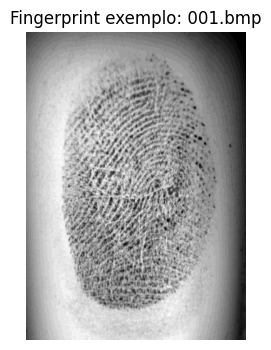

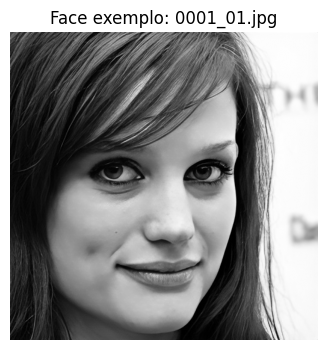

In [13]:

if digitais_files:
    img_fp = load_gray(digitais_files[0])
    show_image(img_fp, f"Fingerprint exemplo: {digitais_files[0].name}")

if faces_files:
    img_face = load_gray(faces_files[0])
    show_image(img_face, f"Face exemplo: {faces_files[0].name}")


## 5. Pipeline ruim para fingerprints

### Decisões ruins introduzidas de propósito
1. Três loops separados (`CLAHE`, equalização, blur);
2. Cada loop cria **novas cópias** da imagem;
3. Há imagens intermediárias em memória sem necessidade;
4. O resultado final é salvo em disco;
5. Pequenos sleeps opcionais simulam jitter de I/O;
6. Há repetição de trabalho para aumentar custo.

> O objetivo não é biometria correta, e sim **um pipeline pesado e mal desenhado**.


In [14]:

def fingerprint_bad_pipeline(path: Path, save_dir: Path) -> dict:
    t0 = time.perf_counter()
    img = load_gray(path)

    generated = []
    current = img.copy()

    # Loop 1: CLAHE repetido, gerando novas imagens
    for i in range(3):
        tile = 8 + 2 * i
        clahe = cv2.createCLAHE(clipLimit=2.0 + i, tileGridSize=(tile, tile))
        current = clahe.apply(current)
        generated.append(current.copy())

    # Loop 2: equalização repetida
    for i in range(3):
        current = cv2.equalizeHist(current)
        if i % 2 == 0:
            current = cv2.medianBlur(current, 3)
        generated.append(current.copy())

    # Loop 3: blur repetido
    for k in [3, 5, 7]:
        current = cv2.GaussianBlur(current, (k, k), sigmaX=1.2)
        generated.append(current.copy())

    # Operação extra artificial
    stacked_mean = np.mean(np.stack(generated, axis=0), axis=0).astype(np.uint8)
    final = cv2.addWeighted(current, 0.6, stacked_mean, 0.4, 0)

    out_path = save_dir / f"{path.stem}_fp_bad.png"
    cv2.imwrite(str(out_path), final)

    elapsed = time.perf_counter() - t0
    return {
        "kind": "fingerprint",
        "id": path.stem,
        "pid": os.getpid(),
        "input_shape": img.shape,
        "generated_images": len(generated),
        "feature_dim": 0,
        "saved_to_disk": True,
        "task_time_s": elapsed,
        "output_path": str(out_path),
    }


## 6. Pipeline ruim para faces

### Decisões ruins introduzidas de propósito
1. Não salvar em disco, mas criar **cálculo pesado**;
2. Usar FFT e gradientes em repetição;
3. Extrair vetor com histogramas e projeções;
4. Repetir etapas para aumentar diferença de custo entre grupos.

> Aqui o gargalo tende a ser mais **computacional**, enquanto em fingerprints há também um peso de **I/O**.


In [15]:

def face_feature_vector_bad(path: Path) -> dict:
    t0 = time.perf_counter()
    img = load_gray(path).astype(np.float64) / 255.0

    # Resize para custo mais previsível
    img = cv2.resize(img, (128, 128), interpolation=cv2.INTER_LINEAR)

    x = img.copy()
    h, w = x.shape
    fy = np.fft.fftfreq(h).reshape(-1, 1)
    fx = np.fft.fftfreq(w).reshape(1, -1)
    freq_weight = 1.0 + 14.0 * (fx * fx + fy * fy)

    # Loop pesado de propósito
    for _ in range(6):
        f = np.fft.fft2(x)
        x = np.real(np.fft.ifft2(f / freq_weight))
        gx = np.roll(x, -1, axis=0) - np.roll(x, 1, axis=0)
        gy = np.roll(x, -1, axis=1) - np.roll(x, 1, axis=1)
        mag = np.sqrt(gx * gx + gy * gy + 1e-8)
        x = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)

    hist, _ = np.histogram(x.ravel(), bins=64, range=(0.0, 1.0))
    hist = hist.astype(np.float64)
    hist /= hist.sum() + 1e-8

    row_proj = x.mean(axis=1)
    col_proj = x.mean(axis=0)

    feature_vector = np.concatenate([hist, row_proj[:32], col_proj[:32]])

    elapsed = time.perf_counter() - t0
    return {
        "kind": "face",
        "id": path.stem,
        "pid": os.getpid(),
        "input_shape": img.shape,
        "generated_images": 0,
        "feature_dim": int(feature_vector.shape[0]),
        "saved_to_disk": False,
        "task_time_s": elapsed,
        "output_path": "",
    }


## 7. Função geral de despacho por item


In [16]:

def process_task_bad(task: dict, save_dir: Path) -> dict:
    if task["kind"] == "fingerprint":
        return fingerprint_bad_pipeline(task["path"], save_dir)
    elif task["kind"] == "face":
        return face_feature_vector_bad(task["path"])
    else:
        raise ValueError(f"Tipo de tarefa desconhecido: {task['kind']}")


## 8. Baseline sequencial

Primeiro, medimos a execução sequencial. Ela será nossa referência para speedup e eficiência.


In [17]:

def run_sequential_bad(tasks: list[dict], save_dir: Path) -> tuple[list[dict], float]:
    t0 = time.perf_counter()
    results = [process_task_bad(task, save_dir) for task in tasks]
    total = time.perf_counter() - t0
    return results, total

ensure_clean_output(clean=False)

seq_results, seq_time = run_sequential_bad(tasks, DIGITAIS_OUT_DIR)
seq_df = pd.DataFrame(seq_results)

print(f"Tempo sequencial total: {seq_time:.3f} s")
display(seq_df.groupby("kind")[["task_time_s", "generated_images", "feature_dim"]].agg(["count", "mean", "min", "max"]))


Tempo sequencial total: 4.129 s


task_time_s                               generated_images       \
                  count      mean       min       max            count mean   
kind                                                                          
face                 80  0.016087  0.008878  0.035642               80  0.0   
fingerprint          80  0.035456  0.024625  0.050390               80  9.0   

                    feature_dim                   
            min max       count   mean  min  max  
kind                                              
face          0   0          80  128.0  128  128  
fingerprint   9   9          80    0.0    0    0

## 9. Exemplo visual de fingerprint processada


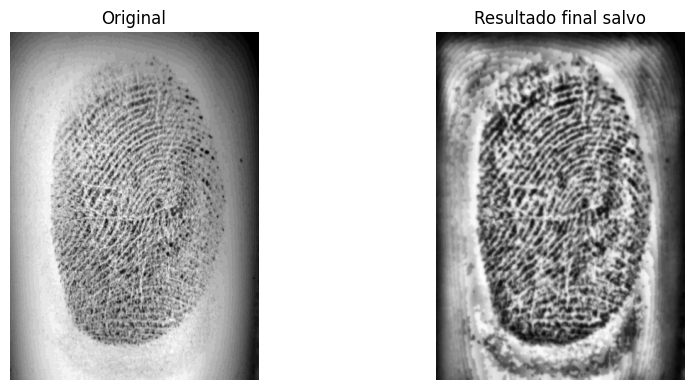

In [18]:

fp_rows = seq_df[seq_df["kind"] == "fingerprint"]
if not fp_rows.empty:
    sample_out = Path(fp_rows.iloc[0]["output_path"])
    if sample_out.exists():
        original = load_gray(digitais_files[0])
        processed = load_gray(sample_out)

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(original, cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(processed, cmap="gray")
        axes[1].set_title("Resultado final salvo")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


## 10. Parallelização ruim e desbalanceada

Agora vamos fazer o que **não** deveríamos fazer em um sistema real:

- particionar por **blocos fixos**;
- usar a ordem original das tarefas;
- deixar cada worker processar sua lista inteira;
- sem rebalanceamento;
- sem task bundling inteligente;
- sem separação entre fingerprints e faces.

Isso produz um excelente material para a aula de profiling.


In [19]:

def worker_process_block(block: list[dict], save_dir_str: str) -> list[dict]:
    save_dir = Path(save_dir_str)
    local_results = []
    for task in block:
        local_results.append(process_task_bad(task, save_dir))
    return local_results

def run_parallel_static_bad(tasks: list[dict], max_workers: int = 4, save_dir: Path | None = None) -> tuple[list[dict], float]:
    if save_dir is None:
        save_dir = DIGITAIS_OUT_DIR

    blocks = chunk_blocks(tasks, max_workers)

    t0 = time.perf_counter()
    results = []
    with ProcessPoolExecutor(max_workers=max_workers) as ex:
        futures = [ex.submit(worker_process_block, block, str(save_dir)) for block in blocks]
        for fut in as_completed(futures):
            results.extend(fut.result())
    total = time.perf_counter() - t0
    return results, total

MAX_WORKERS = min(4, os.cpu_count() or 4)
par_results, par_time = run_parallel_static_bad(tasks, max_workers=MAX_WORKERS, save_dir=DIGITAIS_OUT_DIR)
par_df = pd.DataFrame(par_results)

print(f"Workers usados: {MAX_WORKERS}")
print(f"Tempo paralelo total: {par_time:.3f} s")


Workers usados: 4
Tempo paralelo total: 1.351 s


In [20]:

comparison = pd.DataFrame({
    "modo": ["sequencial", "paralelo_estatico_ruim"],
    "tempo_total_s": [seq_time, par_time],
})
comparison["speedup_vs_seq"] = [1.0, speedup(seq_time, par_time)]
comparison["eficiencia"] = [1.0, efficiency(seq_time, par_time, MAX_WORKERS)]
display(comparison)


,modo,tempo_total_s,speedup_vs_seq,eficiencia
0,sequencial,4.128651,1.000000,1.000000
1,paralelo_estatico_ruim,1.351271,3.055383,0.763846


## 11. Carga por worker

Aqui está a evidência do desbalanceamento.


,pid,task_time_s,share_%
0,1213,1.291605,30.136947
1,1214,1.290560,30.112554
2,1215,0.853923,19.924536
3,1216,0.849698,19.825963


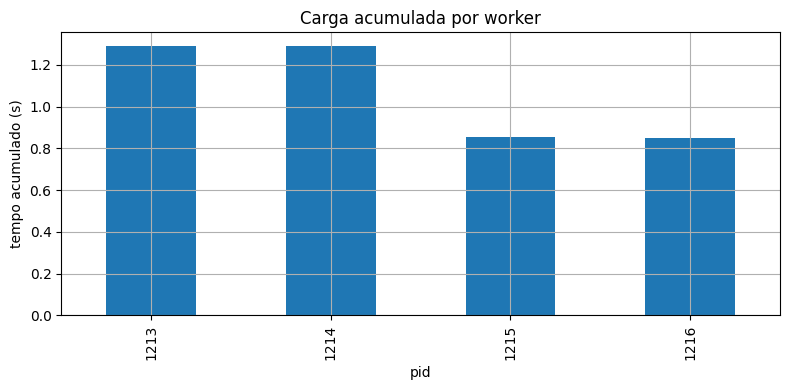

In [21]:

worker_load = (
    par_df.groupby("pid")[["task_time_s"]]
    .sum()
    .sort_values("task_time_s", ascending=False)
    .reset_index()
)
worker_load["share_%"] = 100 * worker_load["task_time_s"] / worker_load["task_time_s"].sum()
display(worker_load)

ax = worker_load.plot.bar(x="pid", y="task_time_s", legend=False, title="Carga acumulada por worker")
ax.set_ylabel("tempo acumulado (s)")
plt.tight_layout()
plt.show()


In [22]:

mix_by_worker = (
    par_df.groupby(["pid", "kind"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
display(mix_by_worker)


kind,pid,face,fingerprint
0,1213,0,40
1,1214,0,40
2,1215,40,0
3,1216,40,0


## 12. Custo por tipo de tarefa

Este gráfico ajuda a discutir se o problema vem só do particionamento ou também da própria natureza heterogênea dos dados.


,kind,task_time_s,generated_images,feature_dim
0,face,0.016087,0.0,128.0
1,fingerprint,0.035456,9.0,0.0


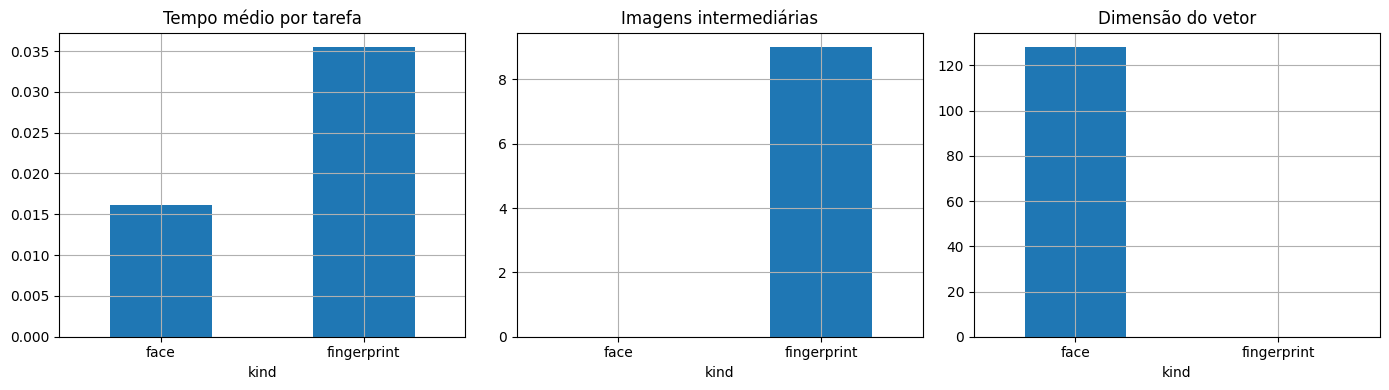

In [23]:

cost_by_kind = (
    seq_df.groupby("kind")[["task_time_s", "generated_images", "feature_dim"]]
    .mean()
    .reset_index()
)
display(cost_by_kind)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cost_by_kind.plot.bar(x="kind", y="task_time_s", ax=axes[0], legend=False, title="Tempo médio por tarefa")
cost_by_kind.plot.bar(x="kind", y="generated_images", ax=axes[1], legend=False, title="Imagens intermediárias")
cost_by_kind.plot.bar(x="kind", y="feature_dim", ax=axes[2], legend=False, title="Dimensão do vetor")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 13. Profiling formal com `cProfile`

Agora vamos confirmar os hotspots com evidência.


In [24]:

profile_subset = tasks[: min(20, len(tasks))]

prof = cProfile.Profile()
prof.enable()
_ = [process_task_bad(task, DIGITAIS_OUT_DIR) for task in profile_subset]
prof.disable()

stats = pstats.Stats(prof).sort_stats("cumulative")
stats.print_stats(25)


         2103 function calls in 0.701 seconds

   Ordered by: cumulative time
   List reduced from 70 to 25 due to restriction <25>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        2    0.000    0.000    0.701    0.350 /home/chaul/hpc_gpu/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3543(run_code)
        2    0.000    0.000    0.701    0.350 {built-in method builtins.exec}
        1    0.000    0.000    0.701    0.701 /tmp/ipykernel_1121/2119865524.py:5(<listcomp>)
       20    0.000    0.000    0.701    0.035 /tmp/ipykernel_1121/575718261.py:1(process_task_bad)
       20    0.002    0.000    0.700    0.035 /tmp/ipykernel_1121/1017211534.py:1(fingerprint_bad_pipeline)
       20    0.363    0.018    0.363    0.018 {imwrite}
       20    0.000    0.000    0.280    0.014 /tmp/ipykernel_1121/901433795.py:8(load_gray)
       20    0.280    0.014    0.280    0.014 {imread}
       20    0.000    0.000    0.022    0.001 /home/chaul/hpc_gpu/lib/

## 14. Diagnóstico guiado

### O que observar
1. O speedup ficou bom?
2. A eficiência está aceitável?
3. Os workers ficaram igualmente ocupados?
4. Fingerprints e faces têm custos parecidos?
5. O maior problema parece ser:
   - I/O?
   - computação?
   - overhead?
   - balanceamento?
   - combinação de fatores?

### Indícios esperados
- fingerprints geram overhead por imagens intermediárias e gravação em disco;
- faces concentram custo computacional;
- blocos estáticos tendem a agrupar tarefas de custo semelhante;
- alguns workers terminam antes e ficam ociosos;
- o throughput global é ditado pelo worker mais lento.


## 15. Hipóteses de otimização para a próxima aula/notebook

Sem implementar agora, pense em como corrigir este desenho ruim:

1. **Task bundling**: processar múltiplas imagens por tarefa de forma mais inteligente;
2. **Particionamento cíclico**: espalhar melhor fingerprints e faces;
3. **Separar pipelines**: fingerprints em um fluxo, faces em outro;
4. **Reduzir cópias intermediárias**: especialmente nos loops de fingerprints;
5. **Evitar escrita excessiva**: salvar só o necessário;
6. **Vetorização/local optimization**: reduzir hotspots internos;
7. **Agendamento dinâmico**: permitir que workers consumam novas tarefas sob demanda.

> Regra central do módulo: **medir → analisar → otimizar → validar**.


## 16. Desafios propostos aos alunos

### Desafio A
Medir novamente usando apenas fingerprints e depois apenas faces. O que muda?

### Desafio B
Alterar o número de workers e observar:
- tempo total;
- speedup;
- eficiência.

### Desafio C
Criar uma função de custo estimado por tarefa e comparar com o tempo real.

### Desafio D
Substituir o particionamento em blocos por um particionamento cíclico.

### Desafio E
Redesenhar o pipeline de fingerprints para fazer `CLAHE`, equalização e blur em uma única função mais enxuta.

### Desafio F
Salvar apenas 10 imagens finais de fingerprint em vez de salvar todas. Qual o impacto?

> Nenhuma modificação deve ser considerada válida sem tabela ou gráfico comparativo.


In [ ]:

# Célula livre para experimentos do aluno/professor
pass
